In [1]:
# node * removeRecursivo(node * l, int info)
#     if l == null
#         return null

#     if l->info != info
#         l->next = removeRecursivo(l->next)
#         return l

#     node * next = l->next;

#     free(l)

#     return next;

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def auc_plot(df: pd.DataFrame) -> None: 
    plt.figure(figsize=(12, 6))
    sns.scatterplot(data=df, x=df.index, y="AUC", hue="AUC", palette="viridis", legend=False, s=80)

    plt.xticks(df.index, df["Dataset"], rotation=90, fontsize=8)

    plt.title("AUC by Dataset", fontsize=14)
    plt.xlabel("Dataset", fontsize=12)
    plt.ylabel("AUC", fontsize=12)
    plt.ylim(0.0, 1.05)
    plt.tight_layout()
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.show()

import os
import pandas as pd
import matplotlib.pyplot as plt
from typing import List

def plot_dataset_sizes(folder_paths: List[str], max_files: int = 100) -> None:
    dataset_names: List[str] = []
    dataset_sizes: List[int] = []

    for folder_path in folder_paths:
        for filename in sorted(os.listdir(folder_path)):
            if filename.endswith(".csv"):
                file_path = os.path.join(folder_path, filename)
                try:
                    df = pd.read_csv(file_path)
                    
                    if len(df) < 50000:
                        dataset_names.append(filename)
                        dataset_sizes.append(len(df))
                except Exception as e:
                    print(f"Failed to read {filename}: {e}")

                if len(dataset_names) >= max_files:
                    break
                
    plt.figure(figsize=(12, 6))
    plt.bar(dataset_names, dataset_sizes, color='skyblue')
    plt.xticks(rotation=90, fontsize=8)
    plt.title("Dataset Sizes (Number of Rows) (Ignorando maiores que 50000)")
    plt.xlabel("Dataset")
    plt.ylabel("Number of Rows")
    plt.tight_layout()
    plt.grid(True, axis='y', linestyle='--', alpha=0.5)
    plt.show()

import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from typing import List

def plot_dataset_columns(folder_paths: List[str], max_files: int = 100) -> None:
    """
    Plots the number of columns in each CSV dataset from the given folder(s).

    Args:
        folder_paths (List[str]): List of folder paths containing CSV files.
        max_files (int): Maximum number of files to read.
    """
    dataset_names: List[str] = []
    cols: List[int] = []
    seen: set = set()

    for folder_path in folder_paths:
        for filename in sorted(os.listdir(folder_path)):
            if not filename.endswith(".csv") or filename in seen:
                continue

            file_path = os.path.join(folder_path, filename)
            try:
                df = pd.read_csv(file_path)
                dataset_names.append(filename)
                cols.append(df.shape[1])
                seen.add(filename)
            except Exception as e:
                print(f"Failed to read {filename}: {e}")

            if len(dataset_names) >= max_files:
                break

    # Plot
    x = np.arange(len(dataset_names))
    plt.figure(figsize=(14, 6))
    plt.bar(x, cols, color='darkorange')

    plt.xticks(ticks=x, labels=dataset_names, rotation=90, fontsize=8)
    plt.title("Number of Columns per Dataset")
    plt.xlabel("Dataset")
    plt.ylabel("Number of Columns")
    plt.tight_layout()
    plt.grid(True, axis='y', linestyle='--', alpha=0.4)
    plt.show()



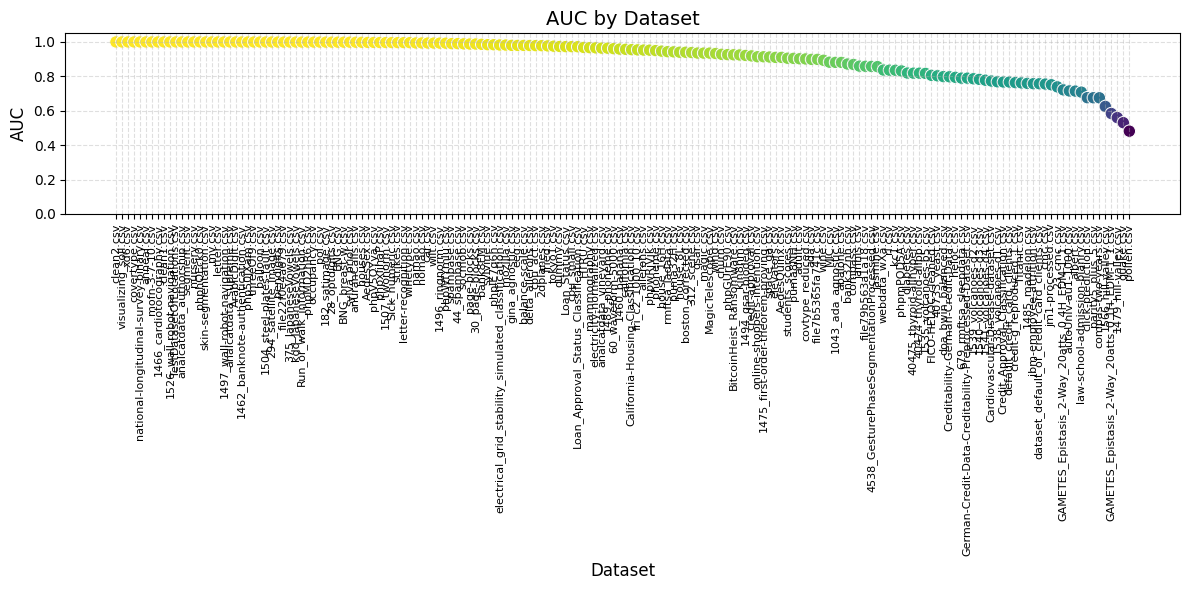

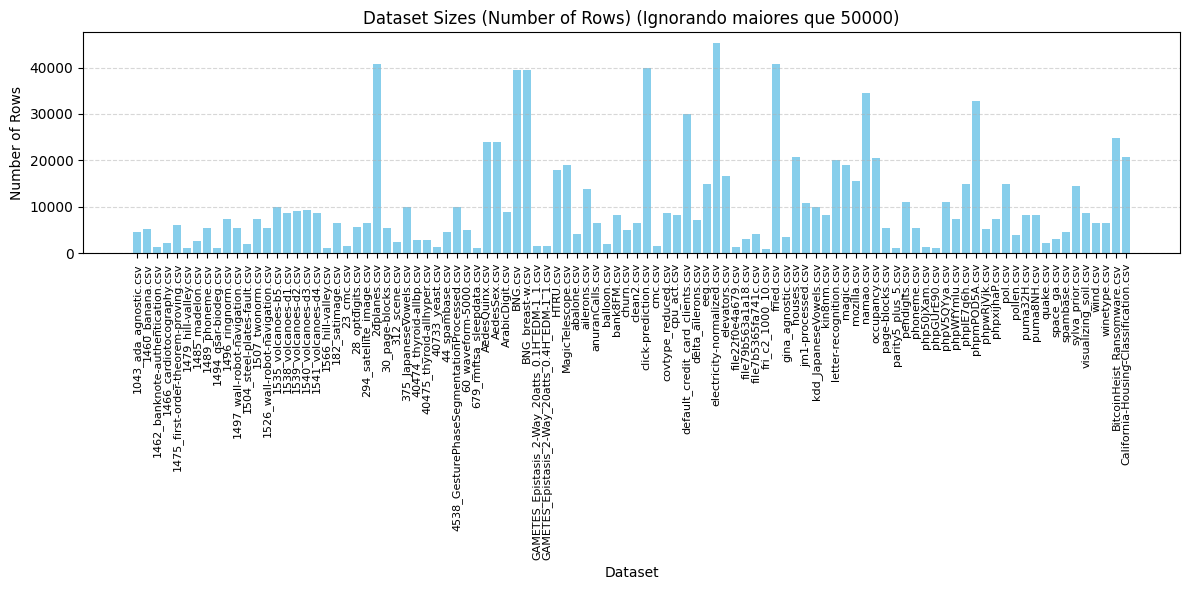

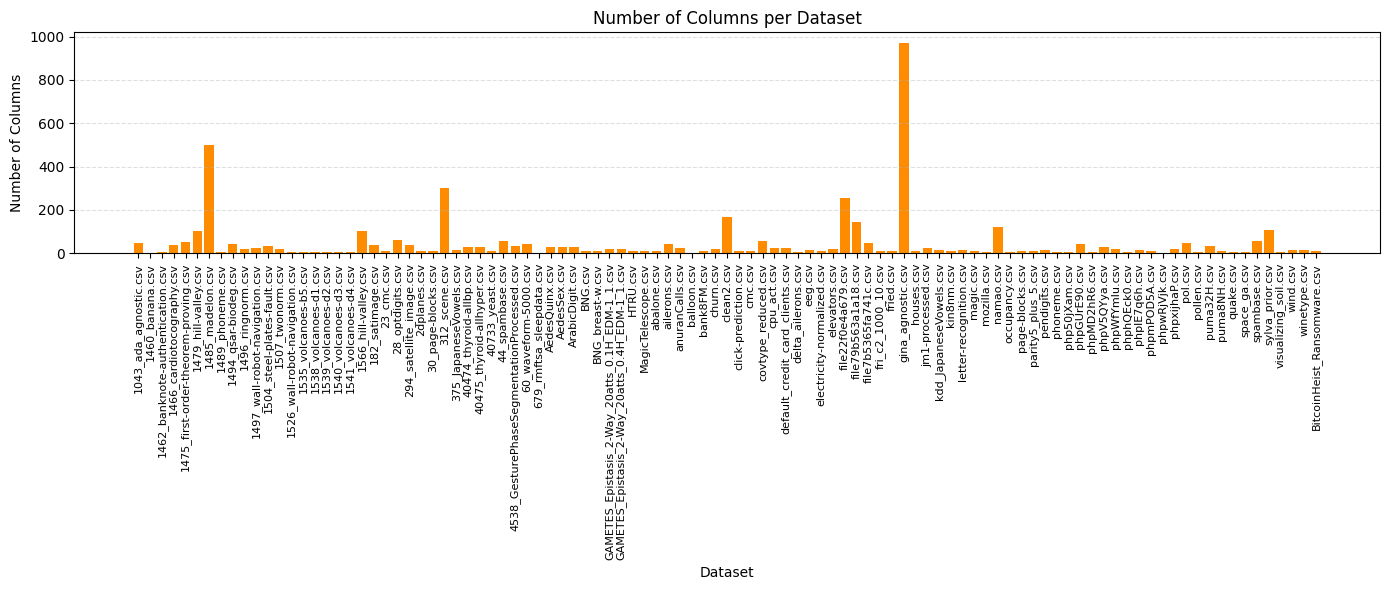

In [4]:
df = pd.concat([pd.read_csv("auc_summary.csv"), pd.read_csv("auc_summary_new.csv")])  
df = df.sort_values("AUC", ascending=False).reset_index(drop=True)

folder_paths = ["OLD_DATASETS", "OLD_DATASETS/NEW_DATASETS"]

auc_plot(df)

plot_dataset_sizes(folder_paths)

plot_dataset_columns(folder_paths)